# Tutorial 1: Experiments on the axolotl telencephalon dataset.

This notebook provides a step-by-step guide on imputing the Juvenile axolotl telencephalon slice and conducting downstream analyses.

In [1]:
# GPU reproducibility and XLA memory setup
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0'

# Import required libraries and dependencies
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as stats
import matplotlib.pyplot as plt

from rosa.model import *
from rosa.utils import *
from rosa.preprocess import *
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# Initialize global settings
seed = 484848
fix_seed(seed, verbose=True)
setup_multigpu_cluster(min_free_ratio=0.5, verbose=True)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

Global random seed set to: 484848.
Multi-GPU cluster configured. JAX will use devices: cuda:0, 1, 2, 3, 4, 5.


In [ ]:
# Load the raw data, and then preprocess them into input data
dataset_name = 'axolotl_telencephalon'
all_slice_names = ['44', '54', '57', 'Juv', 'Adult', 'Meta']
target_slice_name = 'Juv'

adata = read_and_preprocess_data(
    dataset_name=dataset_name,
    all_slice_names=all_slice_names,
    target_slice_name=target_slice_name
)

# Inspect the data structure of adata
adata

Source and target slices have been preprocessed.


AnnData object with n_obs × n_vars = 36198 × 2000
    obs: 'annotation', 'time_point'
    var: 'gene_symbol'
    uns: 'log1p', 'all_slice_names', 'target_slice_name', 'source_slice_names'
    obsm: 'spatial', 'scaled_spatial'
    layers: 'counts'

In [3]:
# Calculate the Dual-Layer Marginal Mass Distribution (DLMMD) of all slices
species = 'human'
n_neighbors = 30
cv_scale_factor = 5.0
trunc_ratio = 0.5
alpha_go = 0.5

compute_dlmmd(
    adata=adata,
    species=species,
    n_neighbors=n_neighbors,
    cv_scale_factor=cv_scale_factor,
    trunc_ratio=trunc_ratio,
    alpha_go=alpha_go
)

# Show marginal mass for a small subset of spots
adata.obs['dlmmd'][:5]

Dual-layer marginal mass distribution have been computed.


CELL.1-44    0.000458
CELL.3-44    0.000494
CELL.4-44    0.000466
CELL.6-44    0.000490
CELL.8-44    0.000584
Name: dlmmd, dtype: float64

In [4]:
# Create a ROSA model and initialize it
epsilon = 2e-2
tau_a, tau_b = 0.999, 0.999
max_gw_iterations, max_sinkhorn_iterations = 100, 1000
gw_threshold, sinkhorn_threshold = 1e-2, 1e-2

rosa = ROSA(
    adata=adata,
    epsilon=epsilon,
    tau_a=tau_a,
    tau_b=tau_b,
    max_gw_iterations=max_gw_iterations,
    max_sinkhorn_iterations=max_sinkhorn_iterations,
    gw_threshold=gw_threshold,
    sinkhorn_threshold=sinkhorn_threshold,
    verbose=True
)

The OT problems are ready for solving.


In [5]:
# Solve all the optimal transport problems
rosa.solve()

# Show the transport matrix from the earliest source slice to the target slice
first_pi = next(iter(rosa.pi_dict.items()))
print('')
print(first_pi)

Computing the OT plan for 44 (1477 spots) -> Juv (11698 spots)...
Computing the OT plan for 54 (2929 spots) -> Juv (11698 spots)...
Computing the OT plan for 57 (4410 spots) -> Juv (11698 spots)...
Computing the OT plan for Adult (8243 spots) -> Juv (11698 spots)...
Computing the OT plan for Meta (7441 spots) -> Juv (11698 spots)...
All OT problems have been solved.
Total training time: 0.3793 minutes.
Total peak GPU memory usage: 2.6272 GB.

('44', Array([[3.33154504e-09, 5.56358204e-09, 1.21754820e-08, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.78652918e-07, 1.01846638e-06, 1.35294295e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.22542814e-06, 6.21253730e-06, 6.33545551e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        4.76424411e-08, 3.31698091e-09, 1.41486312e-09],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
 

In [6]:
# Impute the target slice using barycentric projection
rosa.impute()

# Extract ground‑truth and ROSA‑imputed target slices for evaluation
X_true = adata[adata.obs['time_point'] == target_slice_name].X.toarray()
X_pred = rosa.imputed_X.copy()

Executing barycentric projection for target slice imputation...


The target slice has been imputed.


In [7]:
# Evaluate imputation fidelity on the target slice
gene_pccs = []
for n in range(X_true.shape[1]):
    true_g = X_true[:, n]
    pred_g = X_pred[:, n]
    r, _ = stats.pearsonr(true_g, pred_g)
    gene_pccs.append(r)
mean_gene_pcc = np.nanmean(gene_pccs)

spot_pccs = []
for n in range(X_true.shape[0]):
    true_s = X_true[n, :]
    pred_s = X_pred[n, :]
    r, _ = stats.pearsonr(true_s, pred_s)
    spot_pccs.append(r)
mean_spot_pcc = np.nanmean(spot_pccs)

gene_cs = cosine_similarity(X_true.T, X_pred.T)[np.arange(X_true.shape[1]), np.arange(X_true.shape[1])]
spot_cs = cosine_similarity(X_true, X_pred)[np.arange(X_true.shape[0]), np.arange(X_true.shape[0])]
mean_gene_cs = np.nanmean(gene_cs)
mean_spot_cs = np.nanmean(spot_cs)

print(f'GPCC: {mean_gene_pcc:<.4f}, SPCC: {mean_spot_pcc:<.4f}, GCS: {mean_gene_cs:<.4f}, SCS: {mean_spot_cs:<.4f}.')

GPCC: 0.0960, SPCC: 0.4101, GCS: 0.2741, SCS: 0.4753.


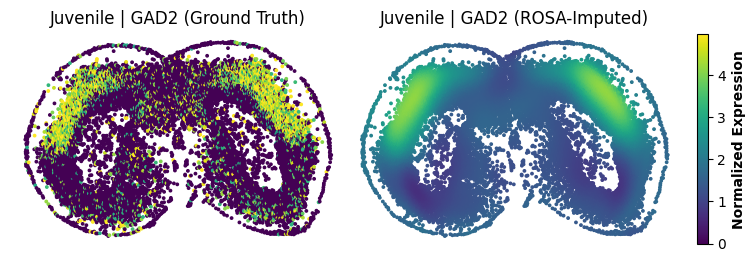

In [17]:
# Visualize ground-truth vs. ROSA-imputed spatial expression maps for GAD2
marker_gene = 'GAD2'
target_mask = adata.obs['time_point'] == target_slice_name
target_coords = adata.obsm['spatial'][target_mask]

gene_idx = list(adata.var['gene_symbol']).index(marker_gene)
expr_true = X_true[:, gene_idx]
expr_pred = X_pred[:, gene_idx]

vmin = np.percentile(expr_true, 5)
vmax = np.percentile(expr_true, 95)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=100)
plt.subplots_adjust(wspace=0.0)

sc0 = axes[0].scatter(
    target_coords[:, 0],
    target_coords[:, 1],
    c=expr_true,
    cmap='viridis',
    s=3,
    vmin=vmin,
    vmax=vmax,
    rasterized=True,
)
axes[0].set_title(f'Juvenile | {marker_gene} (Ground Truth)', fontsize=12)
axes[0].axis('off')
axes[0].set_aspect('equal')

sc1 = axes[1].scatter(
    target_coords[:, 0],
    target_coords[:, 1],
    c=expr_pred,
    cmap='viridis',
    s=3,
    vmin=vmin,
    vmax=vmax,
    rasterized=True,
)
axes[1].set_title(f'Juvenile | {marker_gene} (ROSA-Imputed)', fontsize=12)
axes[1].axis('off')
axes[1].set_aspect('equal')

cbar = fig.colorbar(sc1, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Normalized Expression', fontsize=10, fontweight='bold')

plt.show()

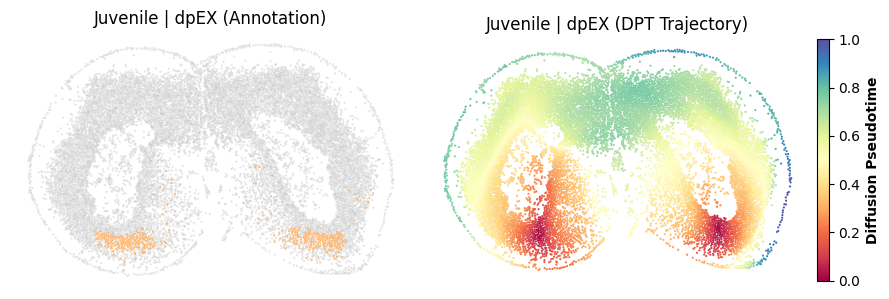

In [ ]:
# Pseudo-spatiotemporal mapping on the Juvenile slice (take dpEX as an example)
target_mask = (adata.obs['time_point'] == target_slice_name).values
adata_p = sc.AnnData(X=X_pred.copy(), obs=adata.obs[target_mask].copy())
adata_p.obsm['spatial'] = adata.obsm['spatial'][target_mask].copy()

sc.pp.scale(adata_p)
sc.pp.pca(adata_p, n_comps=40)
sc.pp.neighbors(adata_p, n_neighbors=30, n_pcs=40)

target_cell_type = 'dpEX'
n_roots = 2
dpex_orange = '#ffbb78'

mask = (adata_p.obs['annotation'] == target_cell_type).values
indices = np.where(mask)[0]
target_spatial = adata_p.obsm['spatial'][mask]

kmeans = KMeans(n_clusters=n_roots, random_state=42, n_init=10)
labels = kmeans.fit_predict(target_spatial)

root_indices = []
for label in range(n_roots):
    cluster_mask = labels == label
    cluster_spatial = target_spatial[cluster_mask]
    cluster_indices = indices[cluster_mask]
    centroid = cluster_spatial.mean(axis=0)
    distances = np.linalg.norm(cluster_spatial - centroid, axis=1)
    root_indices.append(cluster_indices[np.argmin(distances)])

sc.tl.diffmap(adata_p)
dpt_list = []
for root in root_indices:
    adata_p.uns['iroot'] = root
    sc.tl.dpt(adata_p)
    dpt_list.append(adata_p.obs['dpt_pseudotime'].values.copy())

dpt_val = np.minimum.reduce(dpt_list)
spatial_coords = adata_p.obsm['spatial']
annotations = adata_p.obs['annotation'].values
unique_cats = pd.Categorical(adata_p.obs['annotation']).categories

fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=100)

for cat in unique_cats:
    cat_mask = annotations == cat
    c = dpex_orange if cat == target_cell_type else '#AAAAAA'
    alpha_val = 1.0 if cat == target_cell_type else 0.3
    axes[0].scatter(
        spatial_coords[cat_mask, 0],
        spatial_coords[cat_mask, 1],
        c=[c],
        s=2.5,
        alpha=alpha_val,
        edgecolors='none',
        rasterized=True,
    )
axes[0].set_title(f'Juvenile | {target_cell_type} (Annotation)', fontsize=12)
axes[0].axis('off')
axes[0].set_aspect('equal')

sort_idx = np.argsort(-dpt_val)
sc1 = axes[1].scatter(
    spatial_coords[sort_idx, 0],
    spatial_coords[sort_idx, 1],
    c=dpt_val[sort_idx],
    cmap='Spectral',
    s=2.5,
    vmin=0,
    vmax=1,
    edgecolors='none',
    rasterized=True,
)
axes[1].set_title(f'Juvenile | {target_cell_type} (DPT Trajectory)', fontsize=12)
axes[1].axis('off')
axes[1].set_aspect('equal')

cbar = fig.colorbar(sc1, ax=axes[1], orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label('Diffusion Pseudotime', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()